In [1]:
%pip install kaggle
!mkdir -p ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [2]:
!kaggle datasets download -d sudalairajkumar/covid19-in-india
!unzip covid19-in-india.zip

Dataset URL: https://www.kaggle.com/datasets/sudalairajkumar/covid19-in-india
License(s): CC0-1.0
100% 758k/758k [00:00<00:00, 123MB/s]

Archive:  covid19-in-india.zip
  inflating: StatewiseTestingDetails.csv  
  inflating: covid_19_india.csv      
  inflating: covid_vaccine_statewise.csv  


Now, let's load the relevant CSV file into a pandas DataFrame and display its head.

In [3]:
import pandas as pd
df = pd.read_csv('covid_19_india.csv')

display(df.head())

,Sno,Date,Time,State/UnionTerritory,ConfirmedIndianNational,ConfirmedForeignNational,Cured,Deaths,Confirmed
0,1,2020-01-30,6:00 PM,Kerala,1,0,0,0,1
1,2,2020-01-31,6:00 PM,Kerala,1,0,0,0,1
2,3,2020-02-01,6:00 PM,Kerala,2,0,0,0,2
3,4,2020-02-02,6:00 PM,Kerala,3,0,0,0,3
4,5,2020-02-03,6:00 PM,Kerala,3,0,0,0,3


In [4]:
df['Date']=pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  object        
 5   ConfirmedForeignNational  18110 non-null  object        
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.2+ MB


In [5]:
print(df.shape)

(18110, 9)


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18110 entries, 0 to 18109
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype         
---  ------                    --------------  -----         
 0   Sno                       18110 non-null  int64         
 1   Date                      18110 non-null  datetime64[ns]
 2   Time                      18110 non-null  object        
 3   State/UnionTerritory      18110 non-null  object        
 4   ConfirmedIndianNational   18110 non-null  object        
 5   ConfirmedForeignNational  18110 non-null  object        
 6   Cured                     18110 non-null  int64         
 7   Deaths                    18110 non-null  int64         
 8   Confirmed                 18110 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 1.2+ MB


In [7]:
df.duplicated().sum()


np.int64(0)

In [8]:
print(df.isnull().sum())

Sno                         0
Date                        0
Time                        0
State/UnionTerritory        0
ConfirmedIndianNational     0
ConfirmedForeignNational    0
Cured                       0
Deaths                      0
Confirmed                   0
dtype: int64


In [9]:
print(df.columns)

Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed'],
      dtype='object')


In [10]:
df['Recovered']=df['Cured']

In [11]:
df['Active']=df['Confirmed']-(df['Recovered']+df['Deaths'])

In [12]:
df.columns

Index(['Sno', 'Date', 'Time', 'State/UnionTerritory',
       'ConfirmedIndianNational', 'ConfirmedForeignNational', 'Cured',
       'Deaths', 'Confirmed', 'Recovered', 'Active'],
      dtype='object')

In [13]:
# Creating state level summary
state_level_summary = (
    df.groupby("State/UnionTerritory")[['Confirmed',"Deaths","Recovered","Active"]].max().reset_index()
)
state_level_summary.head()

,State/UnionTerritory,Confirmed,Deaths,Recovered,Active
0,Andaman and Nicobar Islands,7548,129,7412,1154
1,Andhra Pradesh,1985182,13564,1952736,211554
2,Arunachal Pradesh,50605,248,47821,4465
3,Assam,576149,5420,559684,56295
4,Bihar,725279,9646,715352,115152


In [14]:
state_level_summary["Death_Rate"] = (state_level_summary["Deaths"] / state_level_summary["Confirmed"].replace(0,pd.NA)) * 100
state_level_summary["Recovery_Rate"] = (state_level_summary["Recovered"] / state_level_summary["Confirmed"].replace(0,pd.NA)) * 100

In [19]:
state_level_summary["Death_Rate"]=state_level_summary["Death_Rate"].round(2)
state_level_summary["Recovery_Rate"]=state_level_summary["Recovery_Rate"].round(2)

/tmp/ipykernel_1096/3359363852.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_10, x='State/UnionTerritory', y='Confirmed',palette=["Green","Pink","Yellow"])
/tmp/ipykernel_1096/3359363852.py:10: UserWarning: 
The palette list has fewer values (3) than needed (10) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=top_10, x='State/UnionTerritory', y='Confirmed',palette=["Green","Pink","Yellow"])


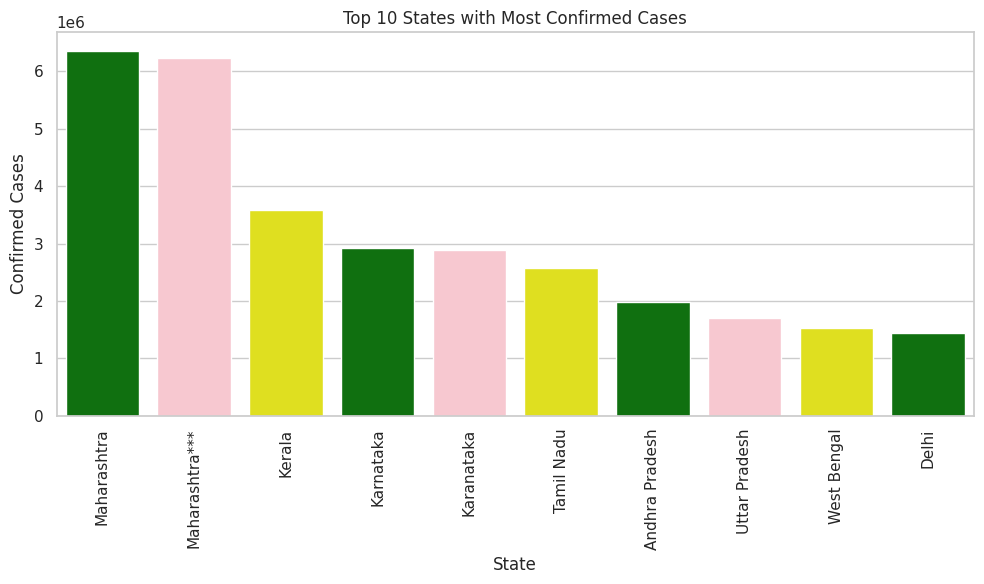

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

top_10 =(
     state_level_summary.sort_values(by='Confirmed', ascending=False).head(10)
)

sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.barplot(data=top_10, x='State/UnionTerritory', y='Confirmed',palette=["Green","Pink","Yellow"])
plt.title('Top 10 States with Most Confirmed Cases')

plt.xlabel('State')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

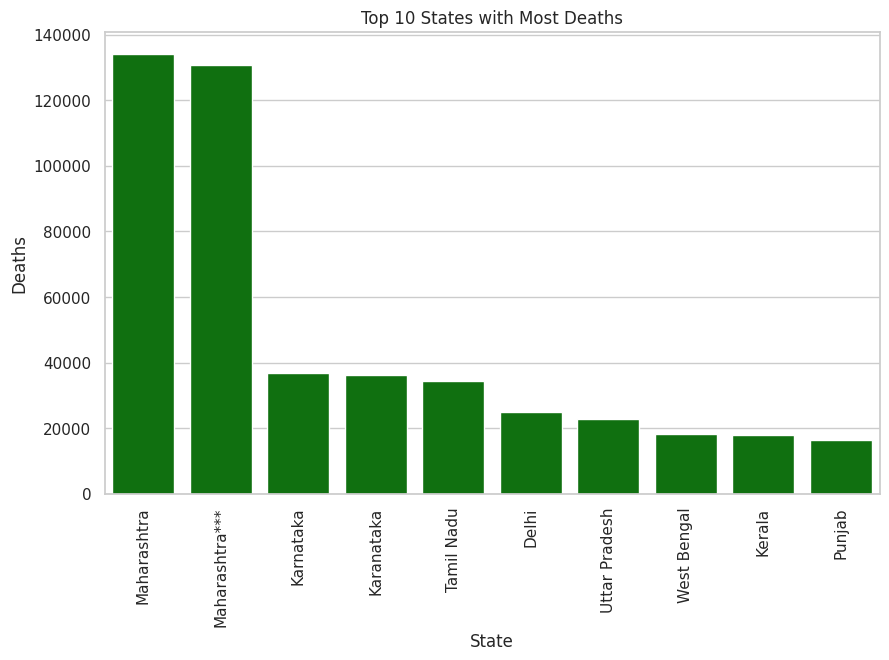

In [17]:
top10=(
    state_level_summary.sort_values("Deaths",ascending=False).head(10)

)
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x='State/UnionTerritory',y='Deaths',color="Green")
plt.xlabel("State")
plt.ylabel("Deaths")
plt.title("Top 10 States with Most Deaths")
plt.xticks(rotation=90)
plt.show()

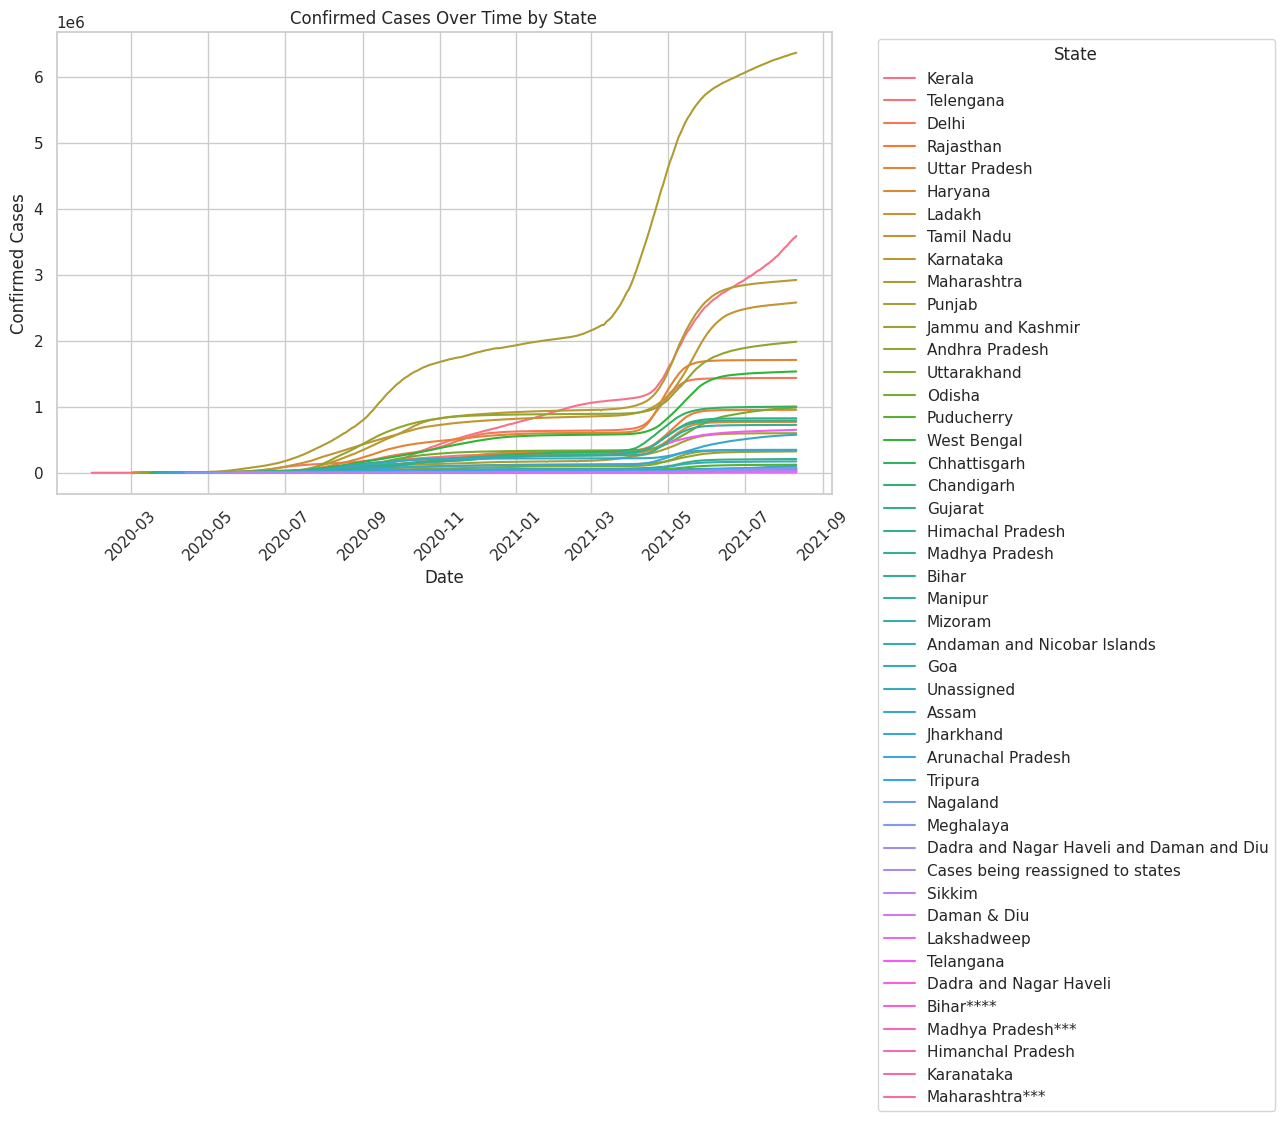

In [18]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x='Date', y='Confirmed',hue='State/UnionTerritory')
plt.title('Confirmed Cases Over Time by State')
plt.xlabel('Date')
plt.ylabel('Confirmed Cases')
plt.xticks(rotation=45)
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()
